In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        os.path.join(dirname, filename)

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
! pip install torch==2.5.1 torchvision==0.20.1 torchaudio==2.5.1 xformers -U
! pip install accelerate datasets transformers
! pip install bitsandbytes
! pip install peft safetensors wandb

INFO: pip is looking at multiple versions of xformers to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.0 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 30.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 2.0 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 85.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.3/15.3 MB 93.3 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.8.93
    Uninstalling

In [3]:
from pathlib import Path
from diffusers import UNet2DConditionModel, AutoencoderKL, DDPMScheduler, StableDiffusionPipeline, DiffusionPipeline
from transformers import CLIPTextModel, CLIPTokenizer
from huggingface_hub import login
from peft import LoraConfig
import torch
from torch.utils.data import DataLoader
from torchvision import transforms
import torch.nn.functional as F
import math
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from peft.utils import get_peft_model_state_dict
from diffusers.utils import convert_state_dict_to_diffusers
from datasets import load_dataset
from functools import partial
from PIL import Image
from kaggle_secrets import UserSecretsClient
from torch.utils.data import Dataset
import pandas as pd
from pydantic import BaseModel
from diffusers.training_utils import compute_snr
from huggingface_hub import notebook_login

2025-04-13 08:21:40.516950: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744532500.787047      31 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744532500.850933      31 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [4]:
notebook_login()

In [5]:
%%capture
!sudo apt -qq install git-lfs
!git config --global credential.helper store

In [6]:
def get_models(model_name,dtype=torch.float16):
    tokenizer = CLIPTokenizer.from_pretrained(model_name, subfolder="tokenizer")
    text_encoder = CLIPTextModel.from_pretrained(model_name, subfolder="text_encoder").to(dtype=dtype)
    vae = AutoencoderKL.from_pretrained(model_name, subfolder="vae").to(dtype=dtype)
    scheduler = DDPMScheduler.from_pretrained(model_name, subfolder="scheduler")
    unet = UNet2DConditionModel.from_pretrained(model_name, subfolder="unet").to(dtype=dtype)
    return tokenizer, text_encoder, vae, scheduler, unet

In [7]:
model_name = 'CompVis/stable-diffusion-v1-4'
tokenizer, text_encoder, vae, scheduler, unet = get_models(model_name)

tokenizer_config.json:   0%|          | 0.00/806 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.06M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

...

diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

scheduler_config.json:   0%|          | 0.00/313 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

# Creating the dataset class and initialising tokenizing the prompts 

In [8]:
from pathlib import Path
import pandas as pd
from PIL import Image
from torchvision import transforms
from torch.utils.data import Dataset

class MidJourneyDataset(Dataset):
    def __init__(self, data_dir, tokenizer):
        self.data_dir = Path(data_dir)
        self.df = pd.read_csv(self.data_dir / 'index.csv')
        self.tokenizer = tokenizer
        self.train_transforms = transforms.Compose([
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5])
        ])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        image_path = self.data_dir / 'images' / self.df.iloc[idx]['image']
        image = Image.open(image_path).convert('RGB')
        image = self.train_transforms(image)
        input_ids = self.tokenizer(
            self.df.iloc[idx]['short_prompt'],
            max_length=self.tokenizer.model_max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )["input_ids"][0]

        return {"pixel_values": image, "input_ids": input_ids}


In [9]:
data_dir = r'/kaggle/input/midjourney-v0/midjourney-512px-v0'
data = MidJourneyDataset(data_dir,tokenizer)


In [10]:
sample = data[0]
sample_image,sample_caption = sample['pixel_values'],sample['input_ids'] 
sample_image.shape,sample_caption.shape

(torch.Size([3, 512, 512]), torch.Size([77]))

In [11]:
num_samples = len(data)
print("Number of samples:", num_samples)

Number of samples: 752


In [12]:
dataloader = DataLoader(data,batch_size=8,shuffle=False)
batch = next(iter(dataloader))
batch_images = batch['pixel_values']
batch_input_ids = batch['input_ids']
print('Batch image tensor shape:',batch_images.shape)
print('Batch caption tensor shape:',batch_input_ids.shape)

Batch image tensor shape: torch.Size([8, 3, 512, 512])
Batch caption tensor shape: torch.Size([8, 77])


# Inspecting the few samples from the dataset

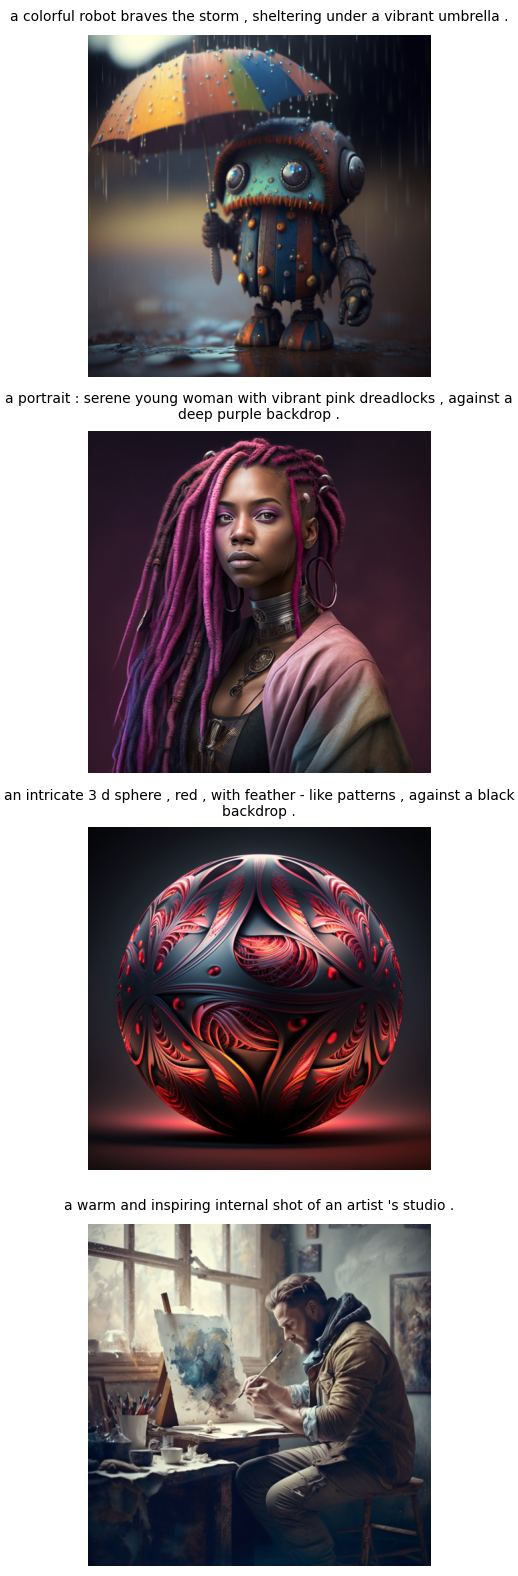

In [13]:
unnormalize = transforms.Normalize(mean=[-1], std=[2])

def decode_caption(input_ids, tokenizer):
    return tokenizer.decode(input_ids, skip_special_tokens=True)

N = 4
fig, axs = plt.subplots(N, 1, figsize=(5, N * 4))

for i in range(N):
    image = batch_images[i]
    caption = decode_caption(batch_input_ids[i], tokenizer)

    image = unnormalize(image)
    image = image.permute(1, 2, 0).cpu().numpy()  
    axs[i].imshow(image)
    axs[i].set_title(caption, fontsize=10, pad=10, wrap=True)
    axs[i].axis('off')

plt.tight_layout()
plt.show()


# Model Setup for LoRA Finetuning

<li> Freeze all model parameters. For LoRa we will add low adapter weights
<li> Config Lora:
- r (rank): Dimensionality of the low-rank matrices.

- lora_alpha: Scaling factor (often same as rank).

- init_lora_weights: How the LoRA weights are initialized (Gaussian distribution here).

- target_modules: The specific layers inside UNet where LoRA will be inserted—typically attention layers (query, key, value, and one output projection)

<li>Injects trainable LoRA adapters into the specified layers of the UNet.

<li> set trainable weights to float32, fp16 can result in instabilty when fine tuning small weights



In [14]:
import bitsandbytes as bnb  

def setup_models_for_training(model_name, rank=128, lr=1e-4, weight_decay=0.01):
    tokenizer, text_encoder, vae, scheduler, unet = get_models(model_name)

    # Freeze unnecessary models
    for m in (unet, text_encoder, vae):
        for p in m.parameters():
            p.requires_grad = False

    # Add LoRA adapter
    unet_lora_config = LoraConfig(
        r=rank,
        lora_alpha=rank,
        init_lora_weights='gaussian',
        target_modules=['to_k', 'to_q', 'to_v', 'to_out.0']
    )
    unet.add_adapter(unet_lora_config)

    # Prepare LoRA trainable params
    for p in unet.parameters():
        if p.requires_grad:
            p.data = p.to(dtype=torch.float32)

    def get_lora_params(unet):
        return [p for p in unet.parameters() if p.requires_grad]

    lora_params = get_lora_params(unet)

    optimizer = bnb.optim.AdamW8bit(
        lora_params,
        lr=lr,
        betas=(0.9, 0.999),
        weight_decay=weight_decay
    )

    return tokenizer, text_encoder, vae, scheduler, unet, optimizer


In [15]:
tokenizer, text_encoder, vae, scheduler, unet, optimizer = setup_models_for_training(model_name) 

In [26]:
class TrainingConfig(BaseModel):
    train_steps: int = 1000 
    num_epochs: int = 10
    lr: float = 1e-4
    lr_warmup_steps: int = 500
    batch_size: int = 1
    accumulation_steps: int = 8
    rank: int = 128 
    max_grad_norm: float = 1.0 
    mixed_precision: str = 'fp16'
    pretrained_name: str = 'CompVis/stable-diffusion-v1-4'
    data_dir: str = '/kaggle/input/midjourney-v0/midjourney-512px-v0'
    eval_batch_size: int = 2
    snr_gamma: float = 5.0
    output_dir: str = 'output-dir'
    save_image_epochs: int = 2 
    save_model_epochs: int = 5
    seed: int = 42
    push_to_hub: bool = True
    hub_private_repo: bool = False
    overwrite_output_dir: bool = True
    resume_from_checkpoint: str = 'checkpoint_dir'

config = TrainingConfig()

In [34]:
import os
from torch import autocast


def make_grid(images, rows, cols):
    w, h = images[0].size
    grid = Image.new('RGB', size=(cols*w, rows*h))
    for i, image in enumerate(images):
        grid.paste(image, box=(i%cols*w, i//cols*h))
    return grid

def evaluate(config, epoch, pipeline):
    # Sample some images from random noise (this is the backward diffusion process).
    # The default pipeline output type is `List[PIL.Image]`
    with autocast("cuda" if torch.cuda.is_available() else "cpu"):

        images = pipeline(
            prompt='A scenic mountain landscape in the style of Studio Ghibli',
            num_inference_steps=50,
            num_images_per_prompt = config.eval_batch_size,
            generator=torch.manual_seed(config.seed),
        ).images

    # Make a grid out of the images
    image_grid = make_grid(images, rows=4, cols=4)

    # Save the images
    test_dir = os.path.join(config.output_dir, "samples")
    os.makedirs(test_dir, exist_ok=True)
    image_grid.save(f"{test_dir}/{epoch:04d}.png")

In [35]:

def train_loop(config, model, vae, text_encoder, tokenizer, noise_scheduler, optimizer, train_dataloader, lr_scheduler):
    train_dataset = MidJourneyDataset(config.data_dir, tokenizer)
    train_dataloader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True)

    logging_dir = os.path.join(config.output_dir, 'logs')
    accelerator_project_config = ProjectConfiguration(project_dir=config.output_dir, logging_dir=logging_dir)

    accelerator = Accelerator(
        mixed_precision=config.mixed_precision,
        gradient_accumulation_steps=config.accumulation_steps,
        log_with="tensorboard",
        project_config=accelerator_project_config,
    )

    if accelerator.is_main_process:
        if config.push_to_hub:
            repo_id = create_repo(repo_id=Path(config.output_dir).name, exist_ok=True).repo_id
        else:
            os.makedirs(config.output_dir, exist_ok=True)
        accelerator.init_trackers("train_lora")

    model, optimizer, train_dataloader, lr_scheduler = accelerator.prepare(
        model, optimizer, train_dataloader, lr_scheduler
    )

    device = accelerator.device
    text_encoder.to(device).eval()
    vae.to(device).eval()
    if hasattr(model, 'enable_xformers_memory_efficient_attention'):
        model.enable_xformers_memory_efficient_attention()
    else:
        print("xformers not supported on this model.")

    model.train()

    # Resume logic
    starting_epoch = 0
    global_step = 0
    if config.resume_from_checkpoint and os.path.exists(config.resume_from_checkpoint):
        accelerator.load_state(config.resume_from_checkpoint)
        state_path = os.path.join(config.resume_from_checkpoint, "training_state.pt")
        if os.path.exists(state_path):
            state_dict = torch.load(state_path)
            starting_epoch = state_dict.get("epoch", 0)
            global_step = state_dict.get("global_step", 0)
            last_loss = state_dict.get("loss", None)
            if last_loss is not None:
                print(f"Resumed from checkpoint. Last recorded loss: {last_loss:.6f}")

    for epoch in range(starting_epoch, config.num_epochs):
        progress_bar = tqdm(total=len(train_dataloader), disable=not accelerator.is_local_main_process)
        progress_bar.set_description(f"Epoch {epoch}")

        for step, batch in enumerate(train_dataloader):
            clean_images = batch["pixel_values"].to(device, dtype=torch.float16 if config.mixed_precision == "fp16" else torch.float32)
            input_ids = batch["input_ids"].to(device)

            with torch.no_grad():
                latents = vae.encode(clean_images).latent_dist.sample()
                latents = latents * vae.config.scaling_factor
                encoder_hidden_states = text_encoder(input_ids)[0]

            noise = torch.randn_like(latents)
            timesteps = torch.randint(0, noise_scheduler.config.num_train_timesteps, (latents.shape[0],), device=latents.device).long()
            noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)

            with accelerator.accumulate(model):
                noise_pred = model(noisy_latents, timesteps, encoder_hidden_states, return_dict=False)[0]

                if config.snr_gamma > 0:
                    snr = compute_snr(noise_scheduler, timesteps)
                    mse_loss_weights = torch.stack([snr, config.snr_gamma * torch.ones_like(timesteps)], dim=1).min(dim=1)[0]
                    mse_loss_weights = mse_loss_weights / snr
                    noise = noise.to(dtype=noise_pred.dtype)
                    loss = F.mse_loss(noise_pred, noise, reduction="none")
                    loss = loss.mean(dim=list(range(1, len(loss.shape)))) * mse_loss_weights
                    loss = loss.mean()
                else:
                    loss = F.mse_loss(noise_pred, noise, reduction="mean")

                accelerator.backward(loss)
                optimizer.step()
                lr_scheduler.step()
                optimizer.zero_grad()

            logs = {
                "loss": loss.detach().item(),
                "lr": lr_scheduler.get_last_lr()[0],
                "step": global_step,
            }
            progress_bar.set_postfix(**logs)
            accelerator.log(logs, step=global_step)
            progress_bar.update(1)
            global_step += 1

        # Evaluate or Save at Epoch End
        if accelerator.is_main_process:
            if (epoch + 1) % config.save_model_epochs == 0 or epoch == config.num_epochs - 1:
                checkpoint_dir = os.path.join(config.output_dir, f"checkpoint-epoch-{epoch}")
                os.makedirs(checkpoint_dir, exist_ok=True)
                accelerator.save_state(checkpoint_dir)
                torch.save({
                    "epoch": epoch + 1,
                    "global_step": global_step,
                    "loss": loss.item(),  
                }, os.path.join(checkpoint_dir, "training_state.pt"))
                print(f" Saved checkpoint at: {checkpoint_dir} (Epoch {epoch + 1}, Step {global_step}, Loss {loss.item():.6f})")


            pipeline = StableDiffusionPipeline(
                unet=accelerator.unwrap_model(model),
                scheduler=noise_scheduler,
                vae=vae,
                text_encoder=text_encoder,
                tokenizer=tokenizer,
                safety_checker=None,
                feature_extractor=None
            )

            if (epoch + 1) % config.save_image_epochs == 0 or epoch == config.num_epochs - 1:
                if evaluate is not None:
                    evaluate(config, epoch, pipeline)

            if (epoch + 1) % config.save_model_epochs == 0 or epoch == config.num_epochs - 1:
                if config.push_to_hub:
                    upload_folder(
                        repo_id=repo_id,
                        folder_path=config.output_dir,
                        commit_message=f"Epoch {epoch}",
                        ignore_patterns=["step_*", "epoch_*"],
                    )
                else:
                    pipeline.save_pretrained(config.output_dir)

    accelerator.end_training()


In [36]:
from torch.optim.lr_scheduler import CosineAnnealingLR
from accelerate import notebook_launcher
from transformers import get_cosine_schedule_with_warmup

tokenizer, text_encoder, vae, scheduler, unet, optimizer = setup_models_for_training(config.pretrained_name)

lr_scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=config.lr_warmup_steps,
    num_training_steps=config.train_steps,
)
args = (
    config,
    unet,
    vae,
    text_encoder,
    tokenizer,
    scheduler,
    optimizer,
    dataloader,  
    lr_scheduler
)
notebook_launcher(train_loop, args=args, num_processes=1)


Launching training on one GPU.


  0%|          | 0/752 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


  0%|          | 0/752 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


...

training_state.pt:   0%|          | 0.00/956 [00:00<?, ?B/s]

events.out.tfevents.1744539738.4c2437fcf260.31.5:   0%|          | 0.00/955k [00:00<?, ?B/s]

0005.png:   0%|          | 0.00/709k [00:00<?, ?B/s]

0007.png:   0%|          | 0.00/596k [00:00<?, ?B/s]

0009.png:   0%|          | 0.00/653k [00:00<?, ?B/s]

In [39]:
%load_ext tensorboard
%tensorboard --logdir output-dir/logs


The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6006 (pid 167), started 0:00:22 ago. (Use '!kill 167' to kill it.)

<IPython.core.display.Javascript object>

In [40]:
%reload_ext tensorboard
%tensorboard --logdir /kaggle/working/output-dir/logs


<IPython.core.display.Javascript object>

In [41]:
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

ea = EventAccumulator("/kaggle/working/output-dir/logs/train_lora")
ea.Reload()

print("Available tags:", ea.Tags()["scalars"])  # Expecting ['loss', 'lr', 'step'] or similar


Available tags: ['loss', 'lr', 'step']


Scalar tags: ['loss', 'lr', 'step']


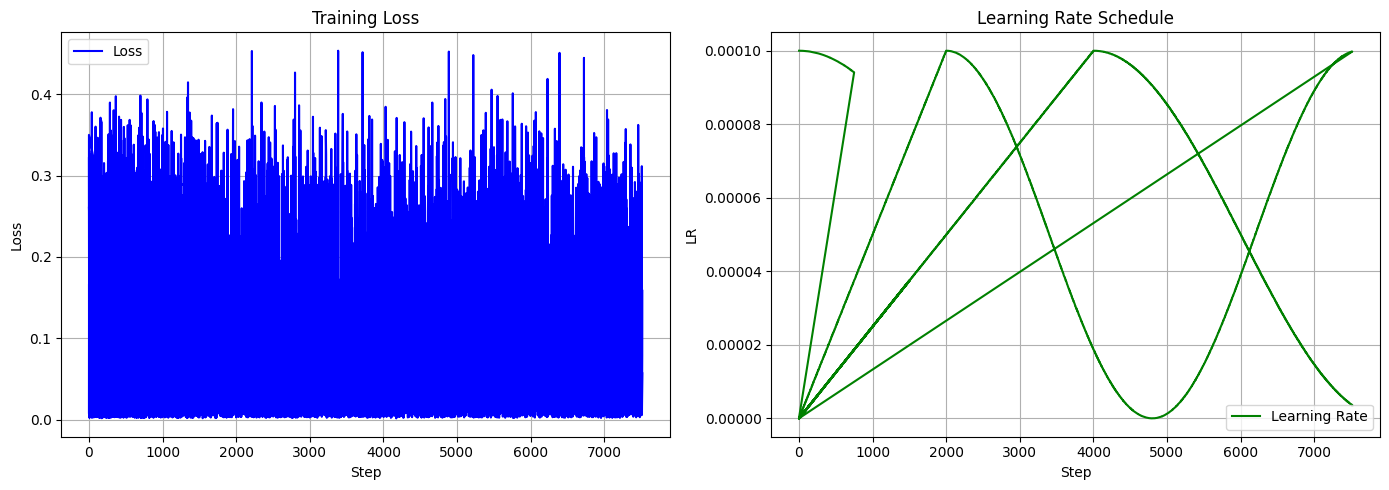

In [43]:
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
import matplotlib.pyplot as plt

log_dir = "/kaggle/working/output-dir/logs/train_lora"
ea = EventAccumulator(log_dir)
ea.Reload()

print("Scalar tags:", ea.Tags()["scalars"])  
loss_events = ea.Scalars("loss")
lr_events = ea.Scalars("lr")

loss_steps = [e.step for e in loss_events]
loss_values = [e.value for e in loss_events]

lr_steps = [e.step for e in lr_events]
lr_values = [e.value for e in lr_events]

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(loss_steps, loss_values, label="Loss", color='blue')
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid(True)
plt.legend()


plt.subplot(1, 2, 2)
plt.plot(lr_steps, lr_values, label="Learning Rate", color='green')
plt.xlabel("Step")
plt.ylabel("LR")
plt.title("Learning Rate Schedule")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


In [45]:
tokenizer, text_encoder, vae, scheduler, unet, optimizer = setup_models_for_training(config.pretrained_name)
checkpoint_path = os.path.join(config.output_dir, "checkpoint-epoch-9")  # adjust to your checkpoint
accelerator = Accelerator()

model, optimizer = accelerator.prepare(unet, optimizer)

accelerator.load_state(checkpoint_path)


In [46]:
from peft import get_peft_model_state_dict
from diffusers.utils import convert_state_dict_to_diffusers
import torch
import os

unet = accelerator.unwrap_model(model)
lora_state_dict = get_peft_model_state_dict(unet)
lora_diffusers_state_dict = convert_state_dict_to_diffusers(lora_state_dict)

save_path = os.path.join(config.output_dir, "lora_weights.bin")
torch.save(lora_diffusers_state_dict, save_path)

print(f"LoRA weights extracted and saved at: {save_path}")


LoRA weights extracted and saved at: output-dir/lora_weights.bin


In [47]:
StableDiffusionPipeline.save_lora_weights(save_directory='output_dir',
                                         unet_lora_layers=lora_diffusers_state_dict,
                                         safe_serialization=True)

In [48]:
!ls -l -h output_dir/pytorch_lora_weights.safetensors


-rw-r--r-- 1 root root 98M Apr 13 11:38 output_dir/pytorch_lora_weights.safetensors


# Comparing inference with and without LoRA weights 

In [50]:
df = pd.read_csv(Path(config.data_dir) / "index.csv")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

prompt_training = [df.iloc[0]["short_prompt"]]
prompt_new = "A scenic mountain landscape in the style of Studio Ghibli"
num_inference_steps=35
seed = 42

In [51]:
def generate(pipeline, prompt, seed):
    generator = torch.Generator(device=device).manual_seed(seed)
    return pipeline(prompt, num_inference_steps=num_inference_steps, generator=generator).images[0]

In [52]:
pipeline_base = StableDiffusionPipeline.from_pretrained(config.pretrained_name,torch_dtype=torch.float16).to(device)

model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 16 files:   0%|          | 0/16 [00:00<?, ?it/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


scheduler_config-checkpoint.json:   0%|          | 0.00/209 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.56k [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/342 [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

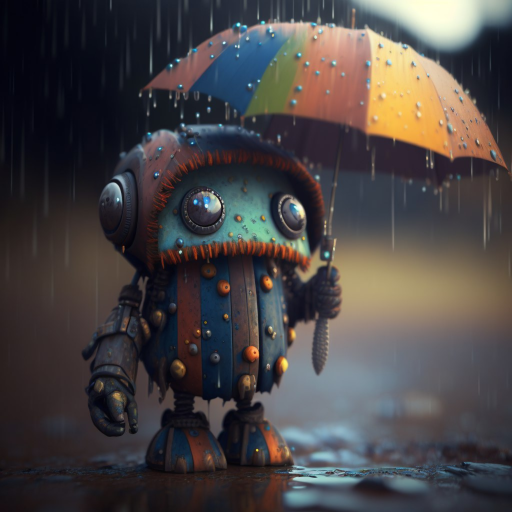

In [53]:
Image.open(Path(config.data_dir) / "images" / df.iloc[0]["image"])


  0%|          | 0/35 [00:00<?, ?it/s]

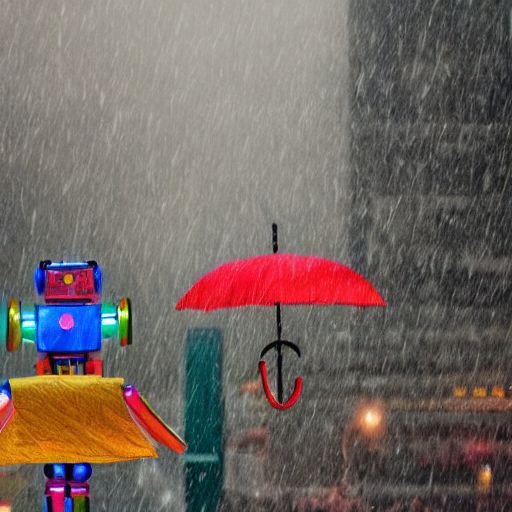

In [54]:
generate(pipeline_base, prompt_training, seed)

In [57]:
pipeline_base.load_lora_weights("output_dir/pytorch_lora_weights.safetensors")


Loading default_0 was unsucessful with the following error: 
CUDA out of memory. Tried to allocate 2.00 MiB. GPU 0 has a total capacity of 14.74 GiB of which 2.12 MiB is free. Process 2539 has 14.74 GiB memory in use. Of the allocated memory 14.56 GiB is allocated by PyTorch, and 38.87 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)


OutOfMemoryError: CUDA out of memory. Tried to allocate 2.00 MiB. GPU 0 has a total capacity of 14.74 GiB of which 2.12 MiB is free. Process 2539 has 14.74 GiB memory in use. Of the allocated memory 14.56 GiB is allocated by PyTorch, and 38.87 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)